In [1]:
# import packages
import pandas as pd
import numpy as np

import re
import string
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
import matplotlib.pyplot as plt

In [2]:
nltk.download('stopwords') #common words to remove
nltk.download('punkt') #tokenizer
nltk.download('wordnet') #for lemmatization
nltk.download('omw-1.4') #open multilingual wordnet

[nltk_data] Downloading package stopwords to C:\Users\UPPL -
[nltk_data]     01\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to C:\Users\UPPL -
[nltk_data]     01\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\UPPL -
[nltk_data]     01\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\UPPL -
[nltk_data]     01\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Text Dataset
WELFake Dataset from [kaggle](https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification)

Dataset contains four columns: 
- Serial number (starting from 0)
-  Title (about the text news heading)
-  Text (about the news content)
-  Label (0 = fake and 1 = real)

For BERT models, only copy and paste the last cell in this section - do not use the rest of the code

In [3]:
df = pd.read_csv("datasets/WELFake_Dataset.csv")   # change path name as needed
df.head()

print(f"Dataset shape: {df.shape}")

Dataset shape: (72134, 4)


In [4]:
# Drop the index column carried over from the original csv
df = df.drop(columns=["Unnamed: 0"])
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [5]:
# Check data types
print("dtypes:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:")
missing_counts = df.isnull().sum()
print(missing_counts)

# Check for missing values
print("\nWhite Spaces:")
whitespace_counts = df.apply(
    lambda col: col.astype(str).str.strip().eq("").sum()
)
print(whitespace_counts)

# Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicate_count}")

# Check distribution
print("\nLabel Distribution")
print(f"Fake news (0): {(df['label'] == 0).sum()} ({(df['label'] == 0).sum()/len(df)*100:.2f}%)")
print(f"Real news (1): {(df['label'] == 1).sum()} ({(df['label'] == 1).sum()/len(df)*100:.2f}%)")

dtypes:
title    object
text     object
label     int64
dtype: object

Missing Values:
title    558
text      39
label      0
dtype: int64

White Spaces:
title      0
text     744
label      0
dtype: int64

Duplicate Rows: 8456

Label Distribution
Fake news (0): 35028 (48.56%)
Real news (1): 37106 (51.44%)


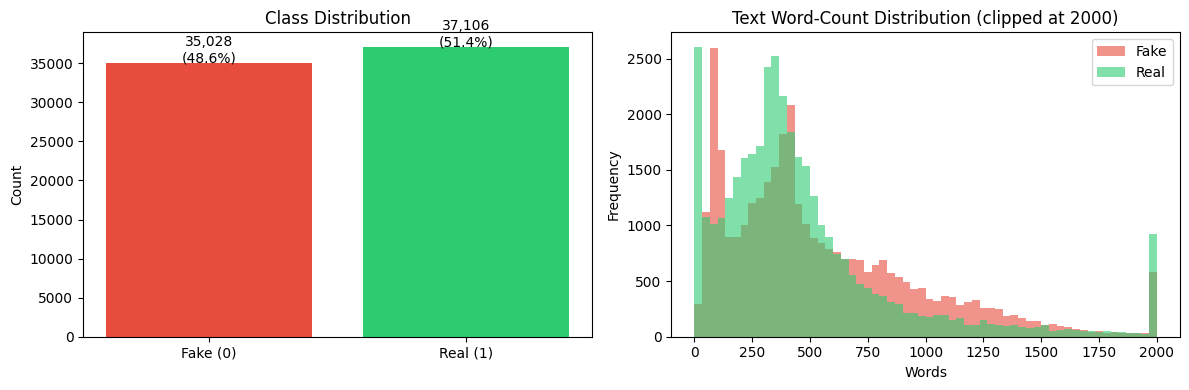


Text word-count stats:
         count   mean    std  min    25%    50%    75%      max
label                                                          
0      35028.0  577.6  563.1  0.0  241.0  427.0  783.0  14641.0
1      37106.0  505.6  677.1  0.0  217.0  369.0  568.0  24234.0

Title word-count stats:
         count  mean  std  min   25%   50%   75%   max
label                                                 
0      35028.0  11.0  2.9  2.0   9.0  11.0  13.0  30.0
1      37106.0  13.2  5.0  0.0  10.0  13.0  16.0  72.0


In [6]:
# --- Class distribution ---
label_counts = df['label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar
axes[0].bar(['Fake (0)', 'Real (1)'], label_counts.values, color=['#e74c3c', '#2ecc71'])
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

# Text-length distribution by class
df['text_len'] = df['text'].fillna('').str.split().str.len()
for lbl, color, name in [(0,'#e74c3c','Fake'), (1,'#2ecc71','Real')]:
    subset = df[df['label'] == lbl]['text_len'].clip(0, 2000)
    axes[1].hist(subset, bins=60, alpha=0.6, color=color, label=name)
axes[1].set_title('Text Word-Count Distribution (clipped at 2000)')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

# Title lengths
df['title_len'] = df['title'].fillna('').str.split().str.len()
print("\nText word-count stats:")
print(df.groupby('label')['text_len'].describe().round(1))
print("\nTitle word-count stats:")
print(df.groupby('label')['title_len'].describe().round(1))

In [8]:
# Very short texts — potential noise
short_thresh = 10  # words
short_texts = df[df['text_len'] < short_thresh]
print(f"Texts with fewer than {short_thresh} words: {len(short_texts)} ({len(short_texts)/len(df)*100:.2f}%)")
short_texts[['title', 'text', 'label']].head(10)

Texts with fewer than 10 words: 1233 (1.71%)


,title,text,label
1,NaN,Did they post their votes for Hillary already?,1
7,HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...,,1
79,‘Arab Spring’ and the Washington-Brussels-Riya...,Be the First to Comment! Search articles,1
106,MARKETWATCH LEFTIST: MSM’s “Blatant” Anti Trum...,,1
185,NaN,Cool,1
244,WORLD WAR 3 IS COMING,source Add To The Conversation Using Facebook ...,1
325,Ohio State University Student Says Terrorist A...,,1
358,NaN,Obamas blunder.,1
364,JULIAN ASSANGE REVEALS John Podesta’s Hilariou...,,1
421,HEATED! TUCKER CARLSON Totally Shuts Down Radi...,https://www.youtube.com/watch?v=RRPSCqkAJgk,1


In [9]:
# Drop rows where title or text is null
df = df.dropna(subset=["title", "text"])

# Drop rows where text is whitespace-only
df = df[df["text"].str.strip() != ""]

# Drop duplicates
df = df.drop_duplicates(subset=["title", "text"])

# Drop very short texts (likely corrupt / empty articles)
df = df[df['text_len'] >= 10]

df = df.reset_index(drop=True)
df.shape

(62338, 5)


Updated Label Distribution
Fake news (0): 34782 (55.80%)
Real news (1): 27556 (44.20%)


Text(0, 0.5, 'Count')

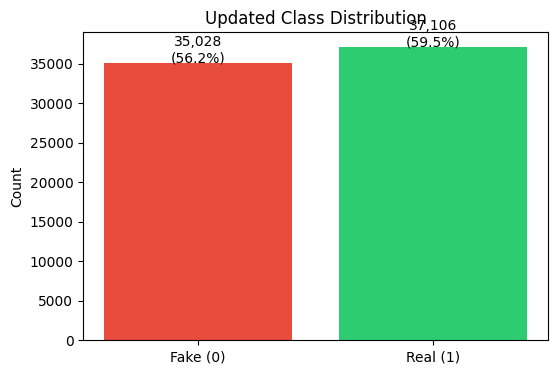

In [15]:
# Check updated distribution
print("\nUpdated Label Distribution")
print(f"Fake news (0): {(df['label'] == 0).sum()} ({(df['label'] == 0).sum()/len(df)*100:.2f}%)")
print(f"Real news (1): {(df['label'] == 1).sum()} ({(df['label'] == 1).sum()/len(df)*100:.2f}%)")

plt.figure(figsize=(6, 4))
plt.bar(['Fake (0)', 'Real (1)'], label_counts.values, color=['#e74c3c', '#2ecc71'])
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.title('Updated Class Distribution')
plt.ylabel('Count')

#### Feature Engineering
Fake news articles tend to be shorter/excessively long

In [16]:
df['title_word_count'] = df['title'].str.split().str.len()
df['text_word_count']  = df['text'].str.split().str.len()
df['text_char_count']  = df['text'].str.len()

print(df[['title_word_count', 'text_word_count', 'text_char_count']].describe().round(1))

       title_word_count  text_word_count  text_char_count
count           62338.0          62338.0          62338.0
mean               12.0            553.5           3344.4
std                 3.8            612.0           3644.9
min                 1.0             10.0             46.0
25%                 9.0            249.0           1509.0
50%                11.0            407.0           2492.0
75%                14.0            683.0           4149.0
max                72.0          24234.0         142961.0


In [17]:
# Negation expansion map
NEGATION_MAP = {
    r"won't": "will not", r"can't": "cannot", r"n't": " not",
    r"'re": " are", r"'s": " is", r"'d": " would",
    r"'ll": " will", r"'ve": " have", r"'m": " am"
}

def expand_contractions(text):
    for pattern, replacement in NEGATION_MAP.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    return text

# POS tag → WordNet POS
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN  # default

# Main Pipeline
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) - {'not', 'no', 'nor'}  # keep negations

def clean_text(text):
    """Full cleaning + tokenisation pipeline. Returns a list of tokens."""
    text = str(text)
    text = expand_contractions(text)         # e.g. don't -> do not
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # remove URLs
    text = re.sub(r'<[^>]+>', ' ', text)                 # strip HTML
    text = re.sub(r'[0-9]+', '', text)                   # remove digits
    text = re.sub(r'[^a-z\s]', ' ', text)               # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()             # normalise whitespace

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if re.match(r'^[a-z]+$', t)]  # alphabetic only
    tokens = [t for t in tokens if t not in stop_words]       # stopword removal

    # POS-aware lemmatisation
    pos_tags = nltk.pos_tag(tokens)
    tokens = [lemmatizer.lemmatize(w, get_wordnet_pos(pos)) for w, pos in pos_tags]
    
    return tokens

df["title_cleaned"] = df["title"].apply(clean_text)
df["text_cleaned"] = df["text"].apply(clean_text)

df.head()

,title,text,label,text_len,title_len,title_word_count,text_word_count,text_char_count,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,871,18,18,871,5049,"[law, enforcement, high, alert, follow, threat...","[no, comment, expect, barack, obama, member, f..."
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,34,18,18,34,216,"[unbelievable, obama, attorney, general, say, ...","[demonstrator, gather, last, night, exercise, ..."
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,1321,16,16,1321,8010,"[bobby, jindal, raise, hindu, us, story, chris...","[dozen, politically, active, pastor, come, pri..."
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,329,16,16,329,1916,"[satan, russia, unvelis, image, terrify, new, ...","[r, sarmat, missile, dub, satan, replace, ss, ..."
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,244,13,13,244,1530,"[time, christian, group, sue, amazon, splc, de...","[say, one, time, someone, sue, southern, pover..."


In [19]:
# Also save as joined strings for TF-IDF / CountVectorizer 
df = df.rename(columns={"title_cleaned": "title_tokens", "text_cleaned": "text_tokens"})

df['title_cleaned'] = df['title_tokens'].apply(lambda t: ' '.join(t)) 
df['text_cleaned'] = df['text_tokens'].apply(lambda t: ' '.join(t))

In [20]:
df.head()

,title,text,label,text_len,title_len,title_word_count,text_word_count,text_char_count,title_tokens,text_tokens,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,871,18,18,871,5049,"[law, enforcement, high, alert, follow, threat...","[no, comment, expect, barack, obama, member, f...",law enforcement high alert follow threat cop w...,no comment expect barack obama member fyf fuky...
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,34,18,18,34,216,"[unbelievable, obama, attorney, general, say, ...","[demonstrator, gather, last, night, exercise, ...",unbelievable obama attorney general say charlo...,demonstrator gather last night exercise consti...
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,1321,16,16,1321,8010,"[bobby, jindal, raise, hindu, us, story, chris...","[dozen, politically, active, pastor, come, pri...",bobby jindal raise hindu us story christian co...,dozen politically active pastor come private d...
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,329,16,16,329,1916,"[satan, russia, unvelis, image, terrify, new, ...","[r, sarmat, missile, dub, satan, replace, ss, ...",satan russia unvelis image terrify new supernu...,r sarmat missile dub satan replace ss fly mile...
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,244,13,13,244,1530,"[time, christian, group, sue, amazon, splc, de...","[say, one, time, someone, sue, southern, pover...",time christian group sue amazon splc designati...,say one time someone sue southern poverty law ...


In [ ]:
df.to_csv("text_data.csv", index=False)

In [ ]:
# for BERT models - copy and paste this cell when needed
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-cased")

encoding = tokenizer(
    df["text"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=512,
    return_tensors="pt"
)

input_ids = encoding['input_ids']
attention_mask = encoding['attention_mask']

# Image Dataset

CASIA v2.0 from [GitHub](https://github.com/namtpham/casia2groundtruth/blob/master/README.md)

Contains: Authentic images (Au) + Tampered images (Tp) + Ground truth masks

Images have mixed sizes (256-800px) and formats (jpg, bmp, tif). The pipeline below resizes them to a uniform 224x224, normalizes pixel values to [0, 1], and applies data augmentation.

The processed dataset will take up a lot of space so copy and paste the code below when training the model.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
# Dataset paths using pathlib
BASE_DIR = Path('datasets/CASIA2.0_revised')  # change path name as needed
AUTHENTIC_DIR = BASE_DIR / 'Au'
TAMPERED_DIR = BASE_DIR / 'Tp'

# .txt list files
AU_LIST_FILE = Path('datasets/CASIA2.0_revised/au_list.txt')
TP_LIST_FILE = Path('datasets/CASIA2.0_revised/tp_list.txt')

print("Dataset Paths:")
print(f"  Base: {BASE_DIR}")
print(f"  Authentic folder: {AUTHENTIC_DIR}")
print(f"  Tampered folder: {TAMPERED_DIR}")
print(f"  Au list file: {AU_LIST_FILE}")
print(f"  Tp list file: {TP_LIST_FILE}")

# Check if paths exist
print("\nPath Check:")
print(f"  Base dir exists: {BASE_DIR.exists()}")
print(f"  Au folder exists: {AUTHENTIC_DIR.exists()}")
print(f"  Tp folder exists: {TAMPERED_DIR.exists()}")
print(f"  Au list exists: {AU_LIST_FILE.exists()}")
print(f"  Tp list exists: {TP_LIST_FILE.exists()}")

Dataset Paths:
  Base: datasets\CASIA2.0_revised
  Authentic folder: datasets\CASIA2.0_revised\Au
  Tampered folder: datasets\CASIA2.0_revised\Tp
  Au list file: datasets\CASIA2.0_revised\au_list.txt
  Tp list file: datasets\CASIA2.0_revised\tp_list.txt

Path Check:
  Base dir exists: True
  Au folder exists: True
  Tp folder exists: True
  Au list exists: True
  Tp list exists: True


In [3]:
# Read authentic image names from txt file
au_names = AU_LIST_FILE.read_text().strip().split('\n')
au_names = [name.strip() for name in au_names if name.strip()]

# Read tampered image names from txt file
tp_names = TP_LIST_FILE.read_text().strip().split('\n')
tp_names = [name.strip() for name in tp_names if name.strip()]

print(f"\nLoaded from txt files:")
print(f"  Authentic images: {len(au_names)}")
print(f"  Tampered images: {len(tp_names)}")
print(f"  Total: {len(au_names) + len(tp_names)}")

# Show sample names
print(f"\nSample authentic names:")
for name in au_names[:3]:
    print(f"  {name}")
    
print(f"\nSample tampered names:")
for name in tp_names[:3]:
    print(f"  {name}")


Loaded from txt files:
  Authentic images: 7491
  Tampered images: 5123
  Total: 12614

Sample authentic names:
  Au_ani_00001.jpg
  Au_ani_00002.jpg
  Au_ani_00003.jpg

Sample tampered names:
  Tp_D_CND_M_N_ani00018_sec00096_00138.tif
  Tp_D_CND_M_N_art00076_art00077_10289.tif
  Tp_D_CND_M_N_art00077_art00076_10290.tif


In [4]:
# Function to get file extension
def get_extension(filename):
    return Path(filename).suffix.lower()

# Count formats in authentic images
au_formats = Counter([get_extension(name) for name in au_names])
print("\nAuthentic Images - File Formats:")
for fmt, count in au_formats.items():
    print(f"  {fmt}: {count} files ({count/len(au_names)*100:.2f}%)")

# Count formats in tampered images
tp_formats = Counter([get_extension(name) for name in tp_names])
print("\nTampered Images - File Formats:")
for fmt, count in tp_formats.items():
    print(f"  {fmt}: {count} files ({count/len(tp_names)*100:.2f}%)")

# All formats combined
all_formats = Counter(list(au_formats.elements()) + list(tp_formats.elements()))
print("\nAll Images - File Formats:")
for fmt, count in all_formats.items():
    print(f"  {fmt}: {count} files")


Authentic Images - File Formats:
  .jpg: 7437 files (99.28%)
  .bmp: 54 files (0.72%)

Tampered Images - File Formats:
  .tif: 3059 files (59.71%)
  .jpg: 2064 files (40.29%)

All Images - File Formats:
  .jpg: 9501 files
  .bmp: 54 files
  .tif: 3059 files


In [6]:
# Check image sizes

def get_image_sizes(names, folder, sample_size=100):
    widths, heights = [], []
    sample = np.random.choice(names, min(sample_size, len(names)), replace=False)
    
    for name in sample:
        try:
            img_path = folder / name
            img = Image.open(img_path)
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except Exception as e:
            print(f"  Error reading {name}: {e}")
    
    return widths, heights

# Analyze authentic images
print("\nAnalyzing authentic images (sample of 100)...")
au_widths, au_heights = get_image_sizes(au_names, AUTHENTIC_DIR)

print(f"Authentic Images Dimensions:")
print(f"  Width  - Min: {min(au_widths)}, Max: {max(au_widths)}, Mean: {np.mean(au_widths):.1f}")
print(f"  Height - Min: {min(au_heights)}, Max: {max(au_heights)}, Mean: {np.mean(au_heights):.1f}")

# Analyze tampered images
print("\nAnalyzing tampered images (sample of 100)...")
tp_widths, tp_heights = get_image_sizes(tp_names, TAMPERED_DIR)

print(f"Tampered Images Dimensions:")
print(f"  Width  - Min: {min(tp_widths)}, Max: {max(tp_widths)}, Mean: {np.mean(tp_widths):.1f}")
print(f"  Height - Min: {min(tp_heights)}, Max: {max(tp_heights)}, Mean: {np.mean(tp_heights):.1f}")

print(f"\nImages have mixed sizes (256-800px range confirmed)")
print(f"Will resize all to 224x224 for uniform input")


Analyzing authentic images (sample of 100)...
Authentic Images Dimensions:
  Width  - Min: 256, Max: 800, Mean: 380.8
  Height - Min: 256, Max: 600, Mean: 315.8

Analyzing tampered images (sample of 100)...
Tampered Images Dimensions:
  Width  - Min: 256, Max: 800, Mean: 450.9
  Height - Min: 256, Max: 700, Mean: 332.6

Images have mixed sizes (256-800px range confirmed)
Will resize all to 224x224 for uniform input


In [8]:
# load images — Au and Tp folders are used as class labels
# Au = Authentic (label 0), Tp = Tampered (label 1)
train_ds = tf.keras.utils.image_dataset_from_directory(
    "datasets/CASIA2.0_revised",  # change path name as needed
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    class_names=["Au", "Tp"]
)

print(train_ds.class_names)

Found 9555 files belonging to 2 classes.
['Au', 'Tp']


In [9]:
# normalize pixel values from [0, 255] to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

In [10]:
# verify image shapes and pixel range after normalization
for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Min pixel value:", tf.reduce_min(images).numpy())
    print("Max pixel value:", tf.reduce_max(images).numpy())

Image shape: (32, 224, 224, 3)
Min pixel value: 0.0
Max pixel value: 1.0


In [11]:
# data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

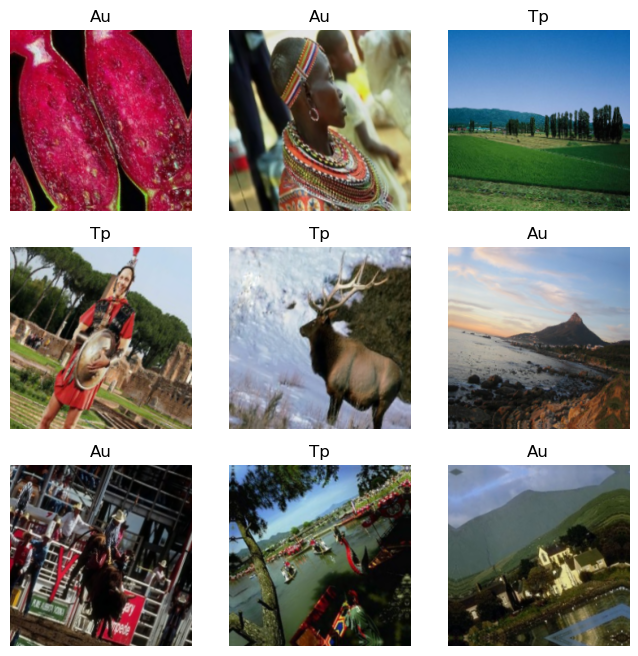

In [12]:
# preview a batch of augmented images
for images, labels in train_ds.take(1):
    plt.figure(figsize=(8, 8))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title("Au" if int(labels[i][0]) == 0 else "Tp")
        plt.axis("off")
    plt.show()

# Audio Dataset

ASVspoof 2019 Logical Access (LA) from [ASVspoof 2019](https://datashare.ed.ac.uk/handle/10283/3336)

Audio: FLAC format
Labels: bonafide (genuine) vs spoof (fake)

In [61]:
import numpy as np
import pandas as pd
from pathlib import Path
import librosa
import librosa.display
import soundfile as sf 
from tqdm import tqdm
import matplotlib.pyplot as plt

print("✓ Packages imported")

✓ Packages imported


In [82]:
# Dataset paths
BASE_DIR = Path('/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 ML/Project/Datasets/Dataset_Audio/LA')
TRAIN_AUDIO_DIR = BASE_DIR / 'ASVspoof2019_LA_train' / 'flac'
DEV_AUDIO_DIR = BASE_DIR / 'ASVspoof2019_LA_dev' / 'flac'
PROTOCOL_DIR = BASE_DIR / 'ASVspoof2019_LA_cm_protocols' 

# Protocol files
TRAIN_PROTOCOL = PROTOCOL_DIR / 'ASVspoof2019.LA.cm.train.trn.txt'
DEV_PROTOCOL = PROTOCOL_DIR / 'ASVspoof2019.LA.cm.dev.trl.txt'

# Config
SAMPLE_RATE = 16000
TARGET_DURATION = 4.0
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

print("Paths configured:")
print(f"  Sample rate: 16 kHz")
print(f"  Format: FLAC")

Paths configured:
  Sample rate: 16 kHz
  Format: FLAC


In [83]:
# Load protocol (labels)

def load_protocol(protocol_file):
    """
    Load protocol: SPEAKER_ID AUDIO_FILE_NAME - SYSTEM_ID KEY
    Returns: DataFrame with audio_file and label
    """
    data = []
    with open(protocol_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            data.append({
                'audio_file': parts[1],
                'system_id': parts[3],
                'label': 0 if parts[4] == 'bonafide' else 1,
                'label_name': parts[4]
            })
    return pd.DataFrame(data)

train_df = load_protocol(TRAIN_PROTOCOL)
dev_df = load_protocol(DEV_PROTOCOL)

print(f"\nTrain: {len(train_df)} samples")
print(f"Dev: {len(dev_df)} samples")
print(f"\nTrain distribution:")
print(train_df['label_name'].value_counts())
display(train_df.head())


Train: 25380 samples
Dev: 24844 samples

Train distribution:
label_name
spoof       22800
bonafide     2580
Name: count, dtype: int64


,audio_file,system_id,label,label_name
0,LA_T_1138215,-,0,bonafide
1,LA_T_1271820,-,0,bonafide
2,LA_T_1272637,-,0,bonafide
3,LA_T_1276960,-,0,bonafide
4,LA_T_1341447,-,0,bonafide


In [84]:
def preprocess_audio(audio_path, sr=16000, duration=4.0):
    """Load audio and extract mel-spectrogram"""
    try:
        # Load and pad/truncate
        audio, _ = librosa.load(audio_path, sr=sr, duration=duration)
        target_length = int(sr * duration)
        
        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)))
        else:
            audio = audio[:target_length]
        
        # Extract mel-spectrogram
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        return mel_spec_db
    except:
        return None

In [85]:
# Use train_df -> later can use dev_df for validate and tune model during training

features = []
labels = []
filenames = []

for idx, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Processing"):
    audio_path = TRAIN_AUDIO_DIR / f"{row['audio_file']}.flac"
    
    if audio_path.exists():
        feature = preprocess_audio(audio_path, SAMPLE_RATE, TARGET_DURATION)
        if feature is not None:
            features.append(feature)
            labels.append(row['label'])
            filenames.append(row['audio_file'])

X_train = np.array(features)
y_train = np.array(labels)
files_train = np.array(filenames)

print(f"\n✓ Training set processed")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")

Processing: 100%|████████████████████████| 25380/25380 [01:54<00:00, 220.88it/s]



✓ Training set processed
  X_train: (25380, 128, 126)
  y_train: (25380,)


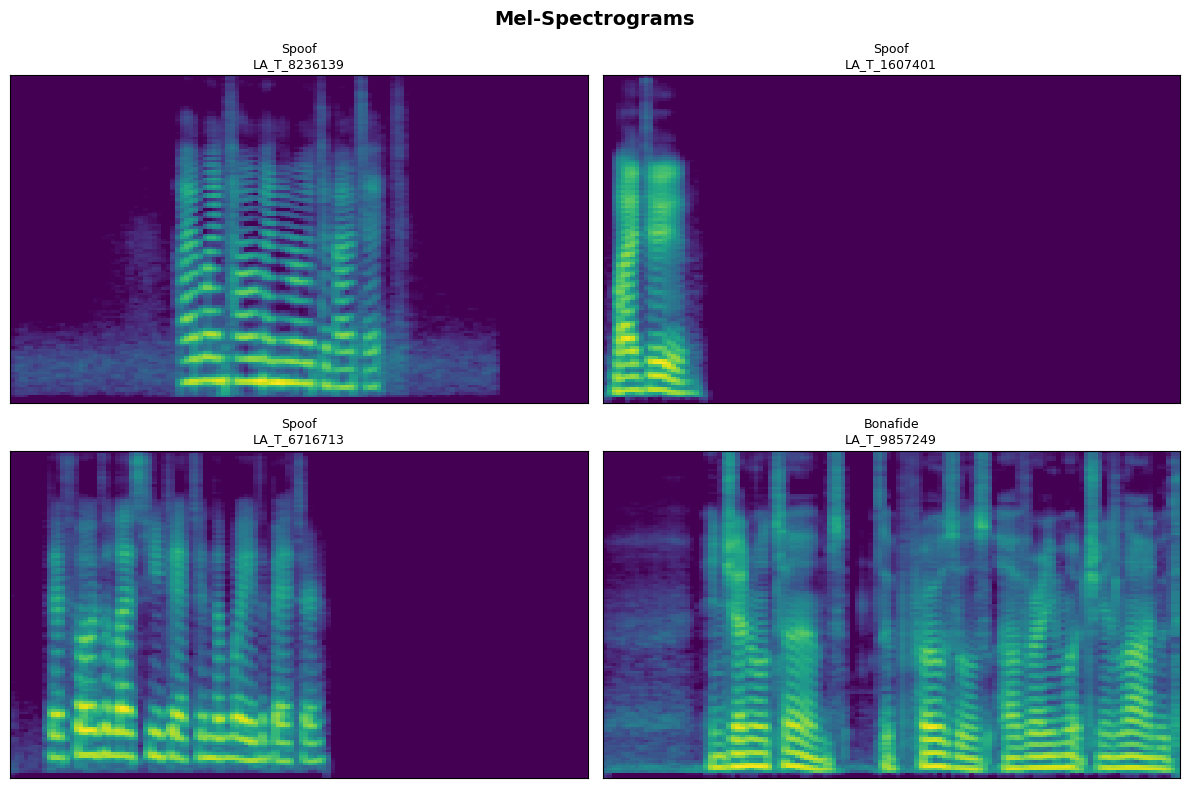

In [91]:
# Show 4 samples
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Mel-Spectrograms', fontsize=14, fontweight='bold')

sample_idx = np.random.choice(len(X_train), 4, replace=False)

for i, idx in enumerate(sample_idx):
    ax = axes[i//2, i%2]
    librosa.display.specshow(X_train[idx], sr=SAMPLE_RATE, ax=ax, cmap='viridis')
    label = 'Bonafide' if y_train[idx] == 0 else 'Spoof'
    ax.set_title(f'{label}\n{files_train[idx][:25]}', fontsize=9)

plt.tight_layout()
plt.show()

## Mel-Spectograms
- X-axis: time --> frequency components
- Y-axis: frequency --> temporal variations
- Colours: Energy/ amplitude in dB (dark purple = low energy; yellow/green = high energy) --> speech energy

*alt, we can try to use LFCC/CQCC (Linear/ Constant Q Cepstral Coefficients) which are usually used for spoofing detection (but more complicated)

In [89]:
OUTPUT_DIR = Path('preprocessed_asvspoof2019')
OUTPUT_DIR.mkdir(exist_ok=True)

np.savez_compressed(
    OUTPUT_DIR / 'asvspoof_train.npz',
    features=X,
    labels=y,
    filenames=files_train
)

print(f"\n✓ Saved to {OUTPUT_DIR}/asvspoof_train.npz")
print(f"✓ DONE!")


✓ Saved to preprocessed_asvspoof2019/asvspoof_train.npz
✓ DONE!
